In [224]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [225]:
df = pd.read_csv('placement.csv')

In [226]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


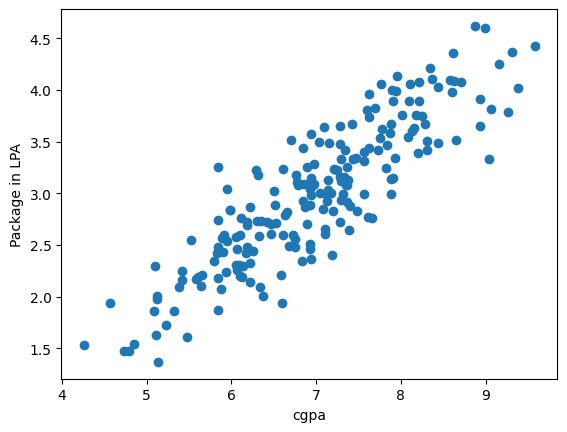

In [227]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa')
plt.ylabel('Package in LPA')
plt.show()

In [228]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [229]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [230]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [231]:
from sklearn.linear_model import LinearRegression

In [232]:
lr = LinearRegression()

In [233]:
lr.fit(X_train, y_train)

LinearRegression()

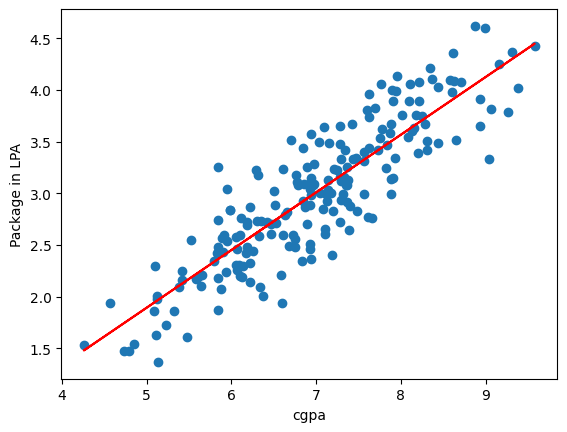

In [234]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X, lr.predict(X), color='red')
plt.xlabel('cgpa')
plt.ylabel('Package in LPA')
plt.show()

In [235]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [236]:
lr.predict(X_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [237]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [238]:
from sklearn.metrics import mean_absolute_percentage_error
y_pred = lr.predict(X_test)
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2", r2_score(y_test,y_pred))
print("MAPE", mean_absolute_percentage_error(y_test,y_pred))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384
MAPE 0.1062335673332732


In [239]:
#Adjusted R2 Score
X_test.shape

(40, 1)

In [240]:
1 - (1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7749598882343415

In [241]:
new_df1 = df.copy()
new_df1['randon_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa', 'randon_feature', 'package']]
new_df1.head()

,cgpa,randon_feature,package
0,6.89,0.044277,3.26
1,5.12,0.155845,1.98
2,7.82,0.569392,3.25
3,7.42,0.619414,3.67
4,6.94,0.599874,3.57


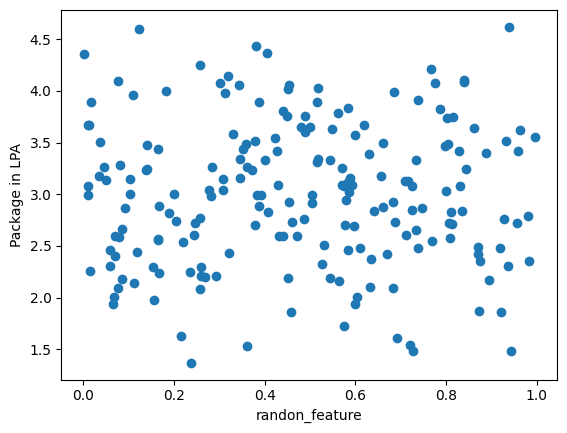

In [242]:
plt.scatter(new_df1['randon_feature'], new_df1['package'])
plt.xlabel('randon_feature')
plt.ylabel('Package in LPA')
plt.show()

In [243]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [244]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [245]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [246]:
y_pred = lr.predict(X_test)

In [247]:
print("R2 Score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score 0.7818376332003547


In [248]:
1 - (1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7700450728328063

In [249]:
new_df2 = new_df1.copy()
new_df2['iq'] = new_df1['package'] + (np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa', 'package', 'iq']]

In [250]:
new_df2.sample(5)

,cgpa,package,iq
37,5.90,2.43,3.43
134,7.20,2.83,3.13
110,8.18,3.76,4.66
52,8.37,4.11,3.71
42,5.95,2.54,2.94


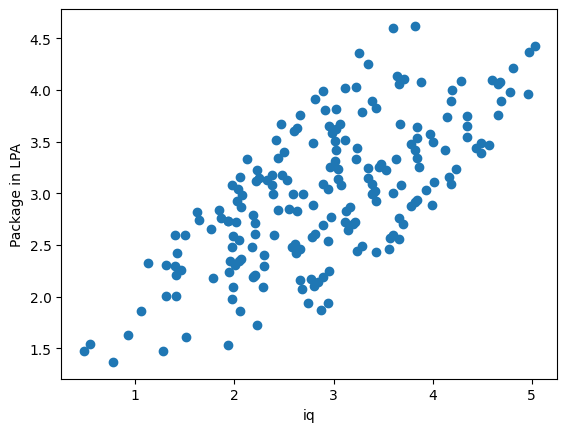

In [251]:
plt.scatter(new_df2['iq'], new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package in LPA')
plt.show()

In [252]:
np.random.randint(-100,100)

1

In [253]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [254]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [255]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [256]:
print("R2 Score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score 0.5497515412074943


In [258]:
1 - (1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-2)

0.5122308363081187